# 12. Sevilla Reviews AI Exploration

Este notebook explora el corpus real de reseñas de Sevilla exportado desde PostgreSQL para preparar el **prototipo IA serio de Hidden Gems**.

Entrada principal:

```text
data/artifacts/ai/sevilla/reviews_for_ai_google_places.jsonl
```

Objetivo:

```text
reviews reales de Google Places Sevilla
→ análisis de calidad
→ análisis territorial
→ análisis textual
→ primeras señales gastronómicas
→ base para detección de platos en español
```

Este notebook **no modifica la base de datos**. Solo lee el JSONL exportado y genera artefactos de exploración en:

```text
data/artifacts/ai/sevilla/exploration/
```

## 1. Configuración inicial

Esta celda prepara rutas relativas al repositorio y crea la carpeta de salida para artefactos.

In [2]:
from pathlib import Path
from collections import Counter
import json
import re
import unicodedata
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 220)
pd.set_option("display.width", 180)

# ------------------------------------------------------------------
# Resolución robusta de PROJECT_DIR
# ------------------------------------------------------------------
CURRENT_DIR = Path.cwd()

def find_project_root(start: Path) -> Path:
    # Busca la raíz del repo subiendo carpetas hasta encontrar README.md y data/.
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "README.md").exists() and (candidate / "data").exists():
            return candidate
    return start

PROJECT_DIR = find_project_root(CURRENT_DIR)

INPUT_PATH = PROJECT_DIR / "data" / "artifacts" / "ai" / "sevilla" / "reviews_for_ai_google_places.jsonl"
SUMMARY_PATH = PROJECT_DIR / "data" / "artifacts" / "ai" / "sevilla" / "reviews_for_ai_google_places_summary.json"

OUTPUT_DIR = PROJECT_DIR / "data" / "artifacts" / "ai" / "sevilla" / "exploration"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("INPUT_PATH:", INPUT_PATH)
print("SUMMARY_PATH:", SUMMARY_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

if not INPUT_PATH.exists():
    raise FileNotFoundError(f"No existe el archivo de entrada: {INPUT_PATH}")

PROJECT_DIR: c:\Users\USUARIO\Documents\Proyectos_Master_IA_Big_Data\hidden-gems-pipeline
INPUT_PATH: c:\Users\USUARIO\Documents\Proyectos_Master_IA_Big_Data\hidden-gems-pipeline\data\artifacts\ai\sevilla\reviews_for_ai_google_places.jsonl
SUMMARY_PATH: c:\Users\USUARIO\Documents\Proyectos_Master_IA_Big_Data\hidden-gems-pipeline\data\artifacts\ai\sevilla\reviews_for_ai_google_places_summary.json
OUTPUT_DIR: c:\Users\USUARIO\Documents\Proyectos_Master_IA_Big_Data\hidden-gems-pipeline\data\artifacts\ai\sevilla\exploration


## 2. Carga del JSONL

Cada línea representa una reseña operativa exportada desde `hidden_gems.review`.

In [3]:
def read_jsonl(path: Path) -> list[dict]:
    rows = []
    invalid = 0

    with path.open("r", encoding="utf-8") as f:
        for line_number, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                invalid += 1
                print(f"JSON inválido en línea {line_number}")

    if invalid:
        raise ValueError(f"Se encontraron {invalid} líneas JSON inválidas.")

    return rows

rows = read_jsonl(INPUT_PATH)
df = pd.DataFrame(rows)

print("Filas cargadas:", len(df))
print("Columnas:", len(df.columns))
display(df.head(3))

Filas cargadas: 4110
Columnas: 27


,review_id,place_id,place_source_ref_id,source_system_code,source_review_id,source_place_record_id,place_source_record_id,place_name,place_canonical_name,address_text,city,neighborhood_id,neighborhood_name,district_id,district_name,rating_value,review_language,review_created_at,review_updated_at,text,text_normalized,is_operational_review,is_training_eligible,source_review_url,place_latitude,place_longitude,text_length_chars
0,0d0946cb-a72c-4197-9d43-b5f3dbfcc620,8cb19db3-e9a8-4a42-be63-73e86e22a3d9,2acb2538-7f10-4760-a646-85c41436f9e8,google_places,a299c238d5349ed3eb5fc64b5db7e6def4db213c4ed81730074b12931536495c,ChIJ50jgAn5tEg0RBySkaJ7I8eE,ChIJ50jgAn5tEg0RBySkaJ7I8eE,Tropitali,Tropitali,"C. San Julián, 13, Casco Antiguo, 41003 Sevilla",Sevilla,e554ef0e-d9f1-4d89-8777-f92cee028f7f,SAN JULIAN,5bd4fbf1-457b-4dcb-91f1-089ac449a5db,Casco Antiguo,5.0,es,2026-05-10T19:07:36.701337+02:00,2026-05-10T19:07:36.701337+02:00,"Sin dudas el mejor Açai que he probado aqui en Sevilla, la coxinha muy rica y el trato del personal increíble, son muy muy muy amables. Gracias por traer un pedacito de Brasil ❤️🇧🇷 volveré y seguro indicaré a mis ami...","Sin dudas el mejor Açai que he probado aqui en Sevilla, la coxinha muy rica y el trato del personal increíble, son muy muy muy amables. Gracias por traer un pedacito de Brasil ❤️🇧🇷 volveré y seguro indicaré a mis ami...",True,True,https://www.google.com/maps/reviews/data=!4m6!14m5!1m4!2m3!1sCi9DQUlRQUNvZENodHljRjlvT21oaWFuRkNhV3RFYUc5TVFVNDJWVGRQZGxkbk5uYxAB!2m1!1s0xd126d7e02e048e7:0xe1f1c89e68a42407,37.399171,-5.985623,221
1,b680ad6e-8999-48a0-a754-84ea920429ab,a6ba370c-eb3d-4456-94cf-58617d1a3b0a,9f4c2eb7-2ff7-44ce-8db2-1be259e6985d,google_places,4897b8c24f949dda32b4e6c5cad74f4a91228c64182c5ce9408158505e192ce0,ChIJuQj13EFvEg0RPkUdEUzL0BA,ChIJuQj13EFvEg0RPkUdEUzL0BA,Cariña VZ,Cariña VZ,"C. Pdte. Cárdenas, 10, 41013 Sevilla",Sevilla,65af0982-2885-49df-9f09-8b784c2f3d7b,GIRALDA SUR,22b433e4-3b14-4b09-bfaa-f0ca1d7e6bdc,Sur,5.0,es,2026-05-10T18:17:25.948671+02:00,2026-05-10T18:17:25.948671+02:00,"Buena comida y con un excelente servicio de Leo que nos atendió y nos explicó todo muy bien, sin duda iremos más de una vez.","Buena comida y con un excelente servicio de Leo que nos atendió y nos explicó todo muy bien, sin duda iremos más de una vez.",True,True,https://www.google.com/maps/reviews/data=!4m6!14m5!1m4!2m3!1sCi9DQUlRQUNvZENodHljRjlvT2sxVGNtOXFka2xKV0daTVNrZFJWRGhZUm1OMVpHYxAB!2m1!1s0xd126f41dcf508b9:0x10d0cb4c111d453e,37.373058,-5.977433,124
2,b2ac02e7-4348-481d-ad2e-cb37ab9c2685,7d39aad6-1d3f-4fc8-8d4b-22896354507e,4fa65ed3-e51a-4a96-b82c-cbe002c03141,google_places,c19ee9e9030a22bbcd80d00ef0680365a36e284ccb72955b931c805b5c37aade,ChIJmU6FwYdvEg0RYLF2daPZQkc,ChIJmU6FwYdvEg0RYLF2daPZQkc,TOTORA,TOTORA,"Av. los Gavilanes, 89, 41006 Sevilla",Sevilla,76a474aa-a390-48b4-a7ad-d68f6d747832,LA PLATA,09b2875d-a826-4c21-bd78-1d8fa48009de,Cerro - Amate,2.0,es,2026-05-10T18:03:34.257906+02:00,2026-05-10T18:03:34.257906+02:00,"Demasiada tiempo de espera para recibir mi pedido\nEl ceviche muy ácido , lo rescatable los anticuchos10/10","Demasiada tiempo de espera para recibir mi pedido El ceviche muy ácido , lo rescatable los anticuchos10/10",True,True,https://www.google.com/maps/reviews/data=!4m6!14m5!1m4!2m3!1sCi9DQUlRQUNvZENodHljRjlvT25Oc2MzRTNhamx2Y0hoa2JqRk5ZekJGUm01dFdYYxAB!2m1!1s0xd126f87c1854e99:0x4742d9a37576b160,37.371563,-5.951597,106


## 3. Validación estructural básica

Comprobamos que el dataset tiene los campos mínimos necesarios para el análisis IA.

In [5]:
REQUIRED_COLUMNS = [
    "review_id",
    "place_id",
    "place_source_ref_id",
    "source_system_code",
    "source_review_id",
    "source_place_record_id",
    "place_name",
    "rating_value",
    "review_language",
    "text",
    "text_normalized",
    "neighborhood_id",
    "neighborhood_name",
    "district_id",
    "district_name",
]

missing_columns = [c for c in REQUIRED_COLUMNS if c not in df.columns]

print("Columnas obligatorias ausentes:", missing_columns)

if missing_columns:
    raise ValueError(f"Faltan columnas obligatorias: {missing_columns}")

# Tipos básicos
df["rating_value"] = pd.to_numeric(df["rating_value"], errors="coerce")
df["text"] = df["text"].fillna("").astype(str)
df["text_normalized"] = df["text_normalized"].fillna(df["text"]).astype(str)
df["review_language"] = df["review_language"].fillna("unknown").astype(str)
df["place_name"] = df["place_name"].fillna("").astype(str)
df["neighborhood_name"] = df["neighborhood_name"].fillna("").astype(str)
df["district_name"] = df["district_name"].fillna("").astype(str)

df["text_length_chars"] = df["text"].str.len()
df["text_length_words"] = df["text"].str.split().str.len()

basic_checks = {
    "has_rows": len(df) > 0,
    "review_ids_are_unique": df["review_id"].nunique(dropna=False) == len(df),
    "source_review_ids_are_unique": df["source_review_id"].nunique(dropna=False) == len(df),
    "all_have_text": (df["text"].str.strip().str.len() > 0).all(),
    "all_have_place": df["place_id"].notna().all(),
    "all_have_place_source_ref": df["place_source_ref_id"].notna().all(),
    "all_have_neighborhood": df["neighborhood_id"].notna().all(),
    "all_have_district": df["district_id"].notna().all(),
    "all_have_rating": df["rating_value"].notna().all(),
}

display(pd.DataFrame([
    {"check": k, "passed": v}
    for k, v in basic_checks.items()
]))

if not all(basic_checks.values()):
    print("Aviso: algún check básico no ha pasado. Revisar antes de continuar.")

Columnas obligatorias ausentes: []


,check,passed
0,has_rows,True
1,review_ids_are_unique,True
2,source_review_ids_are_unique,True
3,all_have_text,True
4,all_have_place,True
5,all_have_place_source_ref,True
6,all_have_neighborhood,True
7,all_have_district,True
8,all_have_rating,True


## 4. Resumen general del corpus

Métricas principales del dataset exportado.

In [6]:
overview = {
    "total_reviews": int(len(df)),
    "unique_places": int(df["place_id"].nunique()),
    "unique_place_source_refs": int(df["place_source_ref_id"].nunique()),
    "unique_neighborhoods": int(df["neighborhood_id"].nunique()),
    "unique_districts": int(df["district_id"].nunique()),
    "source_system_counts": df["source_system_code"].value_counts(dropna=False).to_dict(),
    "language_counts": df["review_language"].value_counts(dropna=False).to_dict(),
    "rating_counts": {str(k): int(v) for k, v in df["rating_value"].value_counts(dropna=False).sort_index().items()},
    "text_length_chars": {
        "min": int(df["text_length_chars"].min()),
        "mean": float(round(df["text_length_chars"].mean(), 4)),
        "median": float(round(df["text_length_chars"].median(), 4)),
        "max": int(df["text_length_chars"].max()),
    },
    "text_length_words": {
        "min": int(df["text_length_words"].min()),
        "mean": float(round(df["text_length_words"].mean(), 4)),
        "median": float(round(df["text_length_words"].median(), 4)),
        "max": int(df["text_length_words"].max()),
    },
}

print(json.dumps(overview, ensure_ascii=False, indent=2))

{
  "total_reviews": 4110,
  "unique_places": 831,
  "unique_place_source_refs": 831,
  "unique_neighborhoods": 96,
  "unique_districts": 11,
  "source_system_counts": {
    "google_places": 4110
  },
  "language_counts": {
    "es": 4108,
    "fr": 1,
    "pt": 1
  },
  "rating_counts": {
    "1.0": 348,
    "2.0": 128,
    "3.0": 210,
    "4.0": 578,
    "5.0": 2846
  },
  "text_length_chars": {
    "min": 24,
    "mean": 354.1068,
    "median": 282.0,
    "max": 3094
  },
  "text_length_words": {
    "min": 3,
    "mean": 61.2798,
    "median": 49.0,
    "max": 570
  }
}


## 5. Distribución por idioma y rating

Analizamos si el corpus es realmente aprovechable para IA en español y cómo se distribuyen las valoraciones.

In [7]:
language_distribution = (
    df["review_language"]
    .value_counts(dropna=False)
    .rename_axis("review_language")
    .reset_index(name="review_count")
)

rating_distribution = (
    df["rating_value"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("rating_value")
    .reset_index(name="review_count")
)

display(language_distribution)
display(rating_distribution)

language_distribution.to_csv(OUTPUT_DIR / "language_distribution.csv", index=False, encoding="utf-8")
rating_distribution.to_csv(OUTPUT_DIR / "rating_distribution.csv", index=False, encoding="utf-8")

,review_language,review_count
0,es,4108
1,fr,1
2,pt,1


,rating_value,review_count
0,1.0,348
1,2.0,128
2,3.0,210
3,4.0,578
4,5.0,2846


<Figure size 800x400 with 0 Axes>

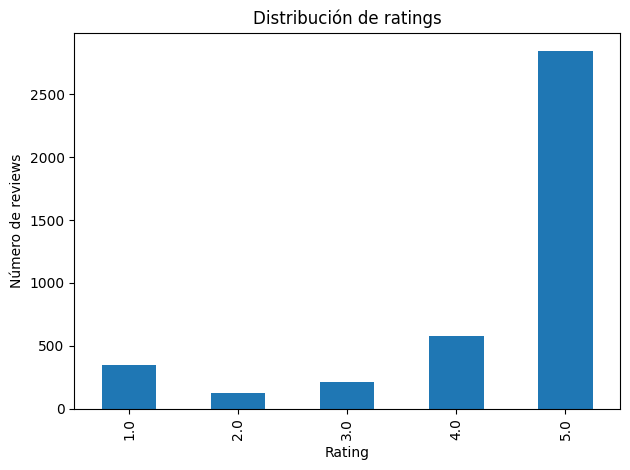

In [8]:
plt.figure(figsize=(8, 4))
rating_distribution.plot(kind="bar", x="rating_value", y="review_count", legend=False)
plt.title("Distribución de ratings")
plt.xlabel("Rating")
plt.ylabel("Número de reviews")
plt.tight_layout()
plt.show()

## 6. Distribución territorial

Revisamos cobertura por distrito y barrio.

In [9]:
district_summary = (
    df.groupby(["district_id", "district_name"], dropna=False)
    .agg(
        review_count=("review_id", "count"),
        place_count=("place_id", "nunique"),
        avg_rating=("rating_value", "mean"),
        avg_text_length_chars=("text_length_chars", "mean"),
    )
    .reset_index()
    .sort_values(["review_count", "place_count"], ascending=False)
)

district_summary["avg_rating"] = district_summary["avg_rating"].round(3)
district_summary["avg_text_length_chars"] = district_summary["avg_text_length_chars"].round(2)

neighborhood_summary = (
    df.groupby(["district_name", "neighborhood_id", "neighborhood_name"], dropna=False)
    .agg(
        review_count=("review_id", "count"),
        place_count=("place_id", "nunique"),
        avg_rating=("rating_value", "mean"),
        avg_text_length_chars=("text_length_chars", "mean"),
    )
    .reset_index()
    .sort_values(["review_count", "place_count"], ascending=False)
)

neighborhood_summary["avg_rating"] = neighborhood_summary["avg_rating"].round(3)
neighborhood_summary["avg_text_length_chars"] = neighborhood_summary["avg_text_length_chars"].round(2)

display(district_summary)
display(neighborhood_summary.head(30))

district_summary.to_csv(OUTPUT_DIR / "district_summary.csv", index=False, encoding="utf-8")
neighborhood_summary.to_csv(OUTPUT_DIR / "neighborhood_summary.csv", index=False, encoding="utf-8")

,district_id,district_name,review_count,place_count,avg_rating,avg_text_length_chars
3,5bd4fbf1-457b-4dcb-91f1-089ac449a5db,Casco Antiguo,936,189,4.421,416.84
2,22b433e4-3b14-4b09-bfaa-f0ca1d7e6bdc,Sur,485,98,4.429,307.69
1,1e467552-511d-4adb-bd9b-257bf108e491,Macarena,453,92,4.309,288.79
4,6af93f2e-b5da-4456-9cb1-e68958a97dbf,Nervión,453,92,4.249,380.19
6,898f9d9e-9365-4138-a30e-d8183ddfa969,San Pablo - Santa Justa,327,66,4.263,322.78
0,09b2875d-a826-4c21-bd78-1d8fa48009de,Cerro - Amate,298,60,3.983,312.20
5,7f42c0b3-14d1-400c-bcde-c128faafc4c5,Este - Alcosa - Torreblanca,294,61,4.313,309.49
7,af2fbf25-5491-4c27-811f-28b7a400ea84,Norte,269,54,4.364,318.88
9,f9420edb-f021-42df-a2cc-e4bb21d0eceb,Triana,230,46,4.470,452.43
8,e1621557-0db9-443a-8065-2fbcb8a9515f,Bellavista - La Palmera,225,45,4.316,355.69


,district_name,neighborhood_id,neighborhood_name,review_count,place_count,avg_rating,avg_text_length_chars
10,Casco Antiguo,8dea766c-0cd6-499c-b34c-2fed439f58df,SANTA CRUZ,188,38,4.351,429.06
5,Casco Antiguo,282de85f-269a-4337-a3b8-75d8ac5fa1ea,ALFALFA,160,32,4.344,417.69
12,Casco Antiguo,ae182ebc-43a4-46db-9364-d006cf3a73c9,ENCARNACIÓN-REGINA,122,25,4.418,382.93
48,Nervión,00162efb-57bb-451d-a462-2bad40efc8b0,LA BUHAIRA,122,25,4.451,399.66
26,Este - Alcosa - Torreblanca,9a832993-14ed-4c5a-b3f9-0ba3ef3898b6,"COLORES, ENTREPARQUES",118,25,4.220,288.91
19,Cerro - Amate,7feeccb6-1f5d-47c2-a067-02dc6466c762,EL CERRO,105,21,4.057,370.93
81,Sur,4cc93289-8e5d-4379-8ca1-74cacb5f263a,EL PORVENIR,105,21,4.267,395.90
94,Triana,b60943da-ab5b-480a-9613-54f47f9dda3b,TRIANA CASCO ANTIGUO,105,21,4.581,463.85
14,Casco Antiguo,dd0845a6-120f-4945-9a3d-ec166c36337c,FERIA,100,20,4.680,457.80
29,Los Remedios,c357d44d-72f6-4501-934e-5df591d621e4,LOS REMEDIOS,100,20,4.170,368.40


<Figure size 1000x600 with 0 Axes>

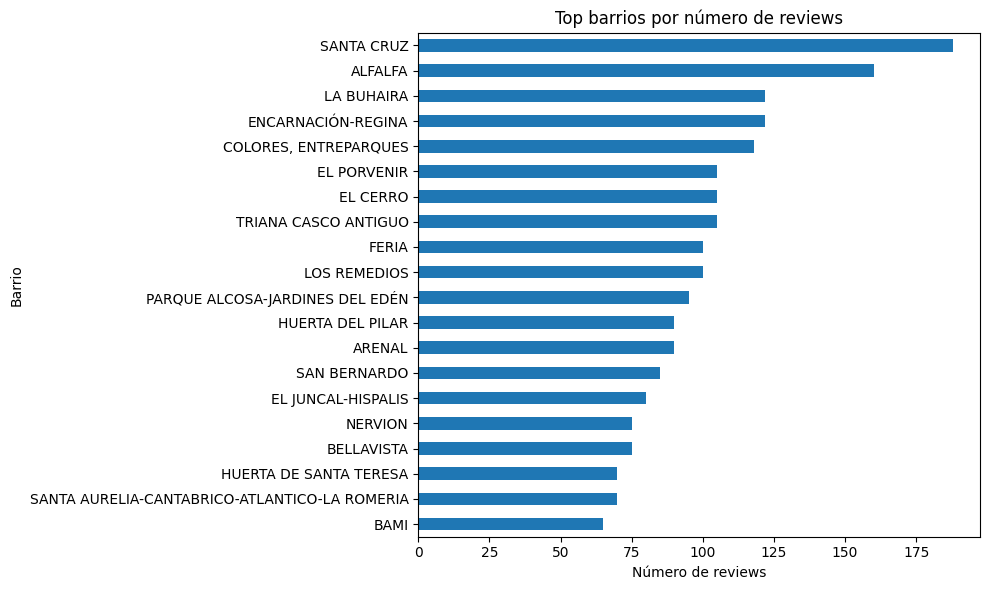

In [10]:
top_neighborhoods = neighborhood_summary.head(20).copy()

plt.figure(figsize=(10, 6))
top_neighborhoods.sort_values("review_count").plot(
    kind="barh",
    x="neighborhood_name",
    y="review_count",
    legend=False,
    figsize=(10, 6),
)
plt.title("Top barrios por número de reviews")
plt.xlabel("Número de reviews")
plt.ylabel("Barrio")
plt.tight_layout()
plt.show()

## 7. Distribución por local

Identificamos locales con más reviews y revisamos si el corpus está muy concentrado.

In [11]:
place_summary = (
    df.groupby(["place_id", "place_name", "district_name", "neighborhood_name"], dropna=False)
    .agg(
        review_count=("review_id", "count"),
        avg_rating=("rating_value", "mean"),
        min_rating=("rating_value", "min"),
        max_rating=("rating_value", "max"),
        avg_text_length_chars=("text_length_chars", "mean"),
    )
    .reset_index()
    .sort_values(["review_count", "avg_rating"], ascending=[False, False])
)

place_summary["avg_rating"] = place_summary["avg_rating"].round(3)
place_summary["avg_text_length_chars"] = place_summary["avg_text_length_chars"].round(2)

display(place_summary.head(30))

place_summary.to_csv(OUTPUT_DIR / "place_summary.csv", index=False, encoding="utf-8")
place_summary.head(100).to_csv(OUTPUT_DIR / "place_summary_top100.csv", index=False, encoding="utf-8")

,place_id,place_name,district_name,neighborhood_name,review_count,avg_rating,min_rating,max_rating,avg_text_length_chars
7,00dac947-a114-4a46-bc61-46466ccfd2b7,Pollos Crispin,Cerro - Amate,EL CERRO,5,5.0,5.0,5.0,533.4
11,02b6f442-7d62-4038-941a-1f440083e396,Red Coffee Sevilla,Casco Antiguo,SAN JULIAN,5,5.0,5.0,5.0,122.0
15,0342cbe1-243b-4548-975f-4309168033a6,Cafeteria Pasteleria Martinez Nene,Cerro - Amate,LA PLATA,5,5.0,5.0,5.0,137.8
16,03522f89-6cd0-469e-97f5-b27e3bc99a9b,Bar Peña Bética San Bernardo,Nervión,SAN BERNARDO,5,5.0,5.0,5.0,170.0
18,03dcbf44-adfa-4e90-9f12-0139061d14fe,Bar LA TRADICIONAL,Sur,EL JUNCAL-HISPALIS,5,5.0,5.0,5.0,254.2
20,04b12323-341e-412f-add1-ed8f7a47ecc6,Bar Piramide,Sur,EL PLANTINAR,5,5.0,5.0,5.0,179.8
21,04e07d33-a35d-48dc-a426-1c9638d39bc8,Berraco Sevilla,Norte,SAN MATIAS,5,5.0,5.0,5.0,304.6
28,0720ea2b-3cfc-420e-a80a-0e073f637942,El Pasaje Santa María la Blanca,Casco Antiguo,SAN BARTOLOME,5,5.0,5.0,5.0,237.8
39,09f2c6ec-dd8e-4862-b923-eedef0347111,La Flor de la Canela,San Pablo - Santa Justa,HUERTA DE SANTA TERESA,5,5.0,5.0,5.0,247.2
40,0a2709cb-4970-42f1-b3d4-78a7b647a590,Bar Doña Lucy - Restaurante paraguayo en Sevilla,Macarena,EL CEREZO,5,5.0,5.0,5.0,253.6


## 8. Longitud de textos

La longitud de las reseñas condiciona la calidad de extracción de platos: textos demasiado cortos suelen aportar poca señal.

In [12]:
length_summary = df[["text_length_chars", "text_length_words"]].describe().round(2)
display(length_summary)

bins = [0, 50, 100, 200, 500, 1000, 2000, 5000, np.inf]
labels = ["0-50", "51-100", "101-200", "201-500", "501-1000", "1001-2000", "2001-5000", "5000+"]

df["text_length_bucket"] = pd.cut(df["text_length_chars"], bins=bins, labels=labels, include_lowest=True)

length_bucket_distribution = (
    df["text_length_bucket"]
    .value_counts()
    .sort_index()
    .rename_axis("text_length_bucket")
    .reset_index(name="review_count")
)

display(length_bucket_distribution)

length_bucket_distribution.to_csv(OUTPUT_DIR / "text_length_bucket_distribution.csv", index=False, encoding="utf-8")

,text_length_chars,text_length_words
count,4110.00,4110.00
mean,354.11,61.28
std,283.46,49.86
min,24.00,3.00
25%,177.25,30.00
50%,282.00,49.00
75%,434.00,76.00
max,3094.00,570.00


,text_length_bucket,review_count
0,0-50,48
1,51-100,284
2,101-200,921
3,201-500,2066
4,501-1000,645
5,1001-2000,133
6,2001-5000,13
7,5000+,0


<Figure size 900x400 with 0 Axes>

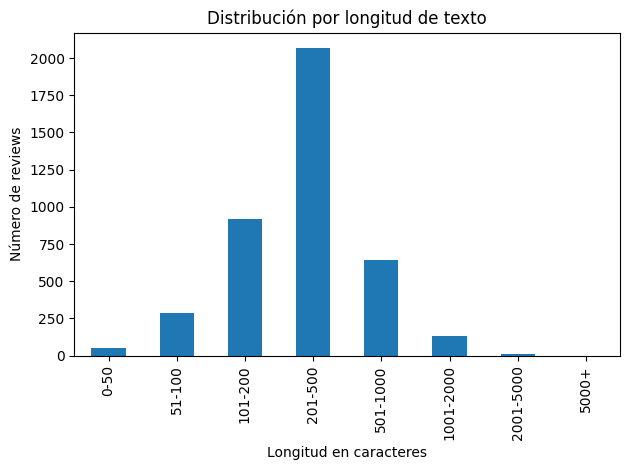

In [13]:
plt.figure(figsize=(9, 4))
length_bucket_distribution.plot(kind="bar", x="text_length_bucket", y="review_count", legend=False)
plt.title("Distribución por longitud de texto")
plt.xlabel("Longitud en caracteres")
plt.ylabel("Número de reviews")
plt.tight_layout()
plt.show()

## 9. Normalización textual auxiliar

Creamos funciones simples de normalización para análisis exploratorio. No sustituyen a la normalización definitiva del módulo IA.

In [14]:
SPANISH_STOPWORDS = {
    "a", "al", "algo", "algunas", "algunos", "ante", "antes", "como", "con", "contra", "cual", "cuando",
    "de", "del", "desde", "donde", "dos", "el", "ella", "ellas", "ellos", "en", "entre", "era", "erais",
    "eran", "eras", "eres", "es", "esa", "esas", "ese", "eso", "esos", "esta", "estaba", "estaban",
    "estado", "estais", "estamos", "estan", "estar", "estas", "este", "esto", "estos", "estoy", "fue",
    "fueron", "fui", "fuimos", "ha", "hace", "hacen", "hacer", "hacia", "han", "hasta", "hay", "he",
    "hemos", "la", "las", "le", "les", "lo", "los", "mas", "me", "mi", "mis", "mucha", "muchas",
    "mucho", "muchos", "muy", "nada", "ni", "no", "nos", "nosotros", "o", "os", "otra", "otras",
    "otro", "otros", "para", "pero", "poco", "por", "porque", "que", "se", "sea", "ser", "si", "sin",
    "sobre", "son", "su", "sus", "tambien", "tan", "tanto", "te", "teneis", "tenemos", "tener", "tengo",
    "ti", "tiene", "tienen", "todo", "todos", "tu", "tus", "un", "una", "uno", "unos", "y", "ya",
    "yo", "vez", "veces", "sitio", "lugar", "local", "restaurante", "bar", "servicio", "personal",
    "comida", "cena", "comer", "plato", "platos", "menu", "menú", "precio", "precios", "calidad", "bien",
    "mal", "bueno", "buena", "buenos", "buenas", "mejor", "peor", "excelente", "genial", "normal"
}

def strip_accents(text: str) -> str:
    if text is None:
        return ""
    text = str(text)
    return "".join(
        c for c in unicodedata.normalize("NFD", text)
        if unicodedata.category(c) != "Mn"
    )

def normalize_for_terms(text: str) -> str:
    text = strip_accents(text).lower()
    text = re.sub(r"[^a-zñ0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_es(text: str) -> list[str]:
    text = normalize_for_terms(text)
    tokens = re.findall(r"[a-z0-9ñ]{2,}", text)
    return [
        token for token in tokens
        if token not in SPANISH_STOPWORDS and not token.isdigit()
    ]

df["text_for_terms"] = df["text"].map(normalize_for_terms)
df["tokens"] = df["text"].map(tokenize_es)

display(df[["text", "tokens"]].head(3))

,text,tokens
0,"Sin dudas el mejor Açai que he probado aqui en Sevilla, la coxinha muy rica y el trato del personal increíble, son muy muy muy amables. Gracias por traer un pedacito de Brasil ❤️🇧🇷 volveré y seguro indicaré a mis ami...","[dudas, acai, probado, aqui, sevilla, coxinha, rica, trato, increible, amables, gracias, traer, pedacito, brasil, volvere, seguro, indicare, amigos]"
1,"Buena comida y con un excelente servicio de Leo que nos atendió y nos explicó todo muy bien, sin duda iremos más de una vez.","[leo, atendio, explico, duda, iremos]"
2,"Demasiada tiempo de espera para recibir mi pedido\nEl ceviche muy ácido , lo rescatable los anticuchos10/10","[demasiada, tiempo, espera, recibir, pedido, ceviche, acido, rescatable, anticuchos10]"


## 10. Términos frecuentes generales

Esto ayuda a entender el vocabulario real de las reseñas, aunque no todos los términos frecuentes son platos.

In [15]:
token_counter = Counter()

for tokens in df["tokens"]:
    token_counter.update(tokens)

top_terms = pd.DataFrame(token_counter.most_common(200), columns=["term", "count"])
display(top_terms.head(50))

top_terms.to_csv(OUTPUT_DIR / "top_terms_overall.csv", index=False, encoding="utf-8")

,term,count
0,buen,873
1,atencion,723
2,tapas,719
3,ambiente,665
4,pedimos,600
5,super,575
6,sevilla,564
7,trato,552
8,carta,530
9,recomendable,530


## 11. Primer lexicón gastronómico en español

Usamos un lexicón inicial amplio para medir cuántas reviews mencionan posibles platos o alimentos.

Este lexicón es exploratorio. En el siguiente notebook se deberá convertir en un detector más serio.

In [16]:
FOOD_TERMS = [
    "croqueta", "croquetas", "tortilla", "tortilla de patatas", "ensaladilla", "salmorejo", "gazpacho",
    "flamenquin", "flamenquín", "carrillada", "solomillo", "presa", "secreto", "lagarto", "abanico",
    "jamon", "jamón", "queso", "chorizo", "morcilla", "montadito", "montaditos", "tosta", "tostas",
    "tapa", "tapas", "racion", "ración", "raciones", "pincho", "pinchos",
    "pescado", "pescaito", "pescaíto", "bacalao", "merluza", "atun", "atún", "salmon", "salmón",
    "pulpo", "chipiron", "chipirón", "chipirones", "calamar", "calamares", "gambas", "langostinos",
    "coquinas", "almejas", "mejillones", "boquerones", "adobo", "choco", "puntillitas",
    "arroz", "paella", "risotto", "pasta", "spaghetti", "espaguetis", "ravioli", "lasagna", "lasaña",
    "carne", "pollo", "ternera", "cerdo", "hamburguesa", "hamburguesas", "burger", "costillas",
    "entrecot", "chuletón", "chuleton", "bistec", "lomo", "albóndigas", "albondigas",
    "pizza", "pizzas", "sushi", "taco", "tacos", "burrito", "burritos", "nachos", "ramen", "bao",
    "wok", "curry", "kebab", "falafel", "hummus", "poke", "poké",
    "tarta", "tartas", "torrija", "torrijas", "helado", "helados", "churros", "chocolate",
    "bizcocho", "brownie", "crepe", "crepes", "tiramisu", "tiramisú", "flan", "natillas",
    "tostada", "tostadas", "mollete", "molletes",
    "patatas", "papas", "bravas", "alioli", "ensalada", "verduras", "berenjena", "berenjenas",
    "setas", "huevos", "huevo", "salsa", "pan",
    "cerveza", "cervezas", "vino", "café", "cafe", "copa", "copas", "cocktail", "cóctel", "mojito"
]

def normalize_term(term: str) -> str:
    return normalize_for_terms(term)

FOOD_TERMS_NORMALIZED = sorted(set(normalize_term(t) for t in FOOD_TERMS), key=len, reverse=True)

def find_food_terms(text: str) -> list[str]:
    normalized = normalize_for_terms(text)
    found = []
    for term in FOOD_TERMS_NORMALIZED:
        pattern = r"(?<!\w)" + re.escape(term) + r"(?!\w)"
        if re.search(pattern, normalized):
            found.append(term)
    return found

df["food_terms_found"] = df["text"].map(find_food_terms)
df["food_term_count"] = df["food_terms_found"].map(len)
df["has_food_term"] = df["food_term_count"] > 0

food_term_counter = Counter()
for terms in df["food_terms_found"]:
    food_term_counter.update(terms)

top_food_terms = pd.DataFrame(food_term_counter.most_common(200), columns=["food_term", "count"])

food_term_summary = {
    "reviews_total": int(len(df)),
    "reviews_with_food_term": int(df["has_food_term"].sum()),
    "reviews_without_food_term": int((~df["has_food_term"]).sum()),
    "share_with_food_term": float(round(df["has_food_term"].mean(), 4)),
    "unique_food_terms_found": int(len(food_term_counter)),
}

print(json.dumps(food_term_summary, ensure_ascii=False, indent=2))
display(top_food_terms.head(50))

top_food_terms.to_csv(OUTPUT_DIR / "top_food_terms_seed_lexicon.csv", index=False, encoding="utf-8")

{
  "reviews_total": 4110,
  "reviews_with_food_term": 2632,
  "reviews_without_food_term": 1478,
  "share_with_food_term": 0.6404,
  "unique_food_terms_found": 124
}


,food_term,count
0,tapas,604
1,cafe,288
2,croquetas,260
3,cerveza,258
4,patatas,214
5,carne,213
6,queso,212
7,pan,197
8,ensaladilla,197
9,jamon,160


## 12. Términos gastronómicos por rating

Permite ver qué platos/comidas aparecen más en reseñas positivas, neutras y negativas.

In [17]:
def rating_to_sentiment_label(rating):
    if pd.isna(rating):
        return "unknown"
    if rating >= 4:
        return "positive"
    if rating == 3:
        return "neutral"
    return "negative"

df["review_sentiment_from_rating"] = df["rating_value"].map(rating_to_sentiment_label)

food_terms_by_sentiment_rows = []

for sentiment, group in df.groupby("review_sentiment_from_rating"):
    counter = Counter()
    for terms in group["food_terms_found"]:
        counter.update(terms)

    for term, count in counter.most_common(100):
        food_terms_by_sentiment_rows.append({
            "sentiment_label": sentiment,
            "food_term": term,
            "count": count,
            "review_count_in_sentiment": len(group),
            "term_share_in_sentiment_reviews": round(count / len(group), 6) if len(group) else 0,
        })

food_terms_by_sentiment = pd.DataFrame(food_terms_by_sentiment_rows)

display(food_terms_by_sentiment.head(60))

food_terms_by_sentiment.to_csv(OUTPUT_DIR / "top_food_terms_by_rating_sentiment.csv", index=False, encoding="utf-8")

,sentiment_label,food_term,count,review_count_in_sentiment,term_share_in_sentiment_reviews
0,negative,cafe,58,476,0.121849
1,negative,patatas,52,476,0.109244
2,negative,pan,46,476,0.096639
3,negative,tapas,42,476,0.088235
4,negative,cerveza,38,476,0.079832
5,negative,tapa,35,476,0.073529
6,negative,pollo,30,476,0.063025
7,negative,tostada,30,476,0.063025
8,negative,carne,30,476,0.063025
9,negative,jamon,27,476,0.056723


## 13. Términos gastronómicos por barrio

Sirve para detectar si hay barrios con señales gastronómicas diferenciales.

In [18]:
food_terms_by_neighborhood_rows = []

for (district, neighborhood), group in df.groupby(["district_name", "neighborhood_name"], dropna=False):
    counter = Counter()
    for terms in group["food_terms_found"]:
        counter.update(terms)

    for term, count in counter.most_common(30):
        food_terms_by_neighborhood_rows.append({
            "district_name": district,
            "neighborhood_name": neighborhood,
            "food_term": term,
            "count": count,
            "review_count_in_neighborhood": len(group),
            "place_count_in_neighborhood": group["place_id"].nunique(),
            "term_share_in_neighborhood_reviews": round(count / len(group), 6) if len(group) else 0,
        })

food_terms_by_neighborhood = pd.DataFrame(food_terms_by_neighborhood_rows)

display(food_terms_by_neighborhood.head(80))

food_terms_by_neighborhood.to_csv(OUTPUT_DIR / "top_food_terms_by_neighborhood_seed_lexicon.csv", index=False, encoding="utf-8")

,district_name,neighborhood_name,food_term,count,review_count_in_neighborhood,place_count_in_neighborhood,term_share_in_neighborhood_reviews
0,Bellavista - La Palmera,BELLAVISTA,cerveza,11,75,15,0.146667
1,Bellavista - La Palmera,BELLAVISTA,tapas,8,75,15,0.106667
2,Bellavista - La Palmera,BELLAVISTA,carne,4,75,15,0.053333
3,Bellavista - La Palmera,BELLAVISTA,patatas,4,75,15,0.053333
4,Bellavista - La Palmera,BELLAVISTA,sushi,3,75,15,0.040000
...,...,...,...,...,...,...,...
75,Bellavista - La Palmera,HELIOPOLIS,montadito,1,30,6,0.033333
76,Bellavista - La Palmera,HELIOPOLIS,huevo,1,30,6,0.033333
77,Bellavista - La Palmera,HELIOPOLIS,chuleton,1,30,6,0.033333
78,Bellavista - La Palmera,HELIOPOLIS,cerveza,1,30,6,0.033333


## 14. Reviews con posibles menciones gastronómicas

Creamos una tabla de inspección manual con ejemplos útiles para el siguiente notebook.

In [21]:
# ============================================================
# 14. Reviews candidatas con términos gastronómicos
# ============================================================

candidate_reviews = df[df["has_food_term"]].copy()

# Seguridad: si por algún motivo no existe food_term_count, se calcula desde food_terms_found
if "food_term_count" not in candidate_reviews.columns:
    candidate_reviews["food_term_count"] = candidate_reviews["food_terms_found"].apply(
        lambda x: len(x) if isinstance(x, list) else 0
    )

manual_columns = [
    "review_id",
    "place_id",
    "place_name",
    "district_name",
    "neighborhood_name",
    "rating_value",
    "review_sentiment_from_rating",
    "review_language",
    "text_length_chars",
    "food_term_count",
    "food_terms_found",
    "text",
]

# Nos quedamos solo con las columnas que existan realmente
manual_columns = [col for col in manual_columns if col in candidate_reviews.columns]

candidate_reviews_for_manual = (
    candidate_reviews[manual_columns]
    .sort_values(["food_term_count", "text_length_chars"], ascending=[False, False])
)

display(candidate_reviews_for_manual.head(30))

candidate_reviews_for_manual.to_csv(
    OUTPUT_DIR / "candidate_reviews_with_food_terms_for_manual_inspection.csv",
    index=False,
    encoding="utf-8"
)

print("Reviews candidatas exportadas:", len(candidate_reviews_for_manual))
print("Archivo guardado en:", OUTPUT_DIR / "candidate_reviews_with_food_terms_for_manual_inspection.csv")

,review_id,place_id,place_name,district_name,neighborhood_name,rating_value,review_sentiment_from_rating,review_language,text_length_chars,food_term_count,food_terms_found,text
506,b152d858-6044-4200-a95f-670b1f5d14ee,b68d347c-9dc8-45d9-b599-b42152896fb3,OMBÚ Los Remedios,Los Remedios,LOS REMEDIOS,4.0,positive,es,1449,15,"[ensaladilla, langostinos, solomillo, croquetas, pescaito, raciones, pescado, racion, tapas, salsa, carne, choco, tosta, atun, cafe]","Es el típico sitio de tapas tradicionales donde se nota que cuidan lo que sale de cocina. En general, una relación calidad-precio muy equilibrada; las raciones no son excesivas pero para nada cortas y la calidad comp..."
2440,5dc0447d-7df8-49da-ab7c-dbf008fb4611,199a8e77-d7ca-4c6b-ac92-9edcfccbf2f0,La Bacalona,Nervión,SAN ROQUE,4.0,positive,es,665,15,"[carrillada, solomillo, verduras, pescado, secreto, ternera, bravas, racion, arroz, salsa, cerdo, pollo, atun, tapa, wok]","Hoy, 13 de octubre, hemos comido allí. Bastante bien. Aunque demasiada oferta de cerdo (solomillo ibérico, carrillada, etc, y nada de ternera o pollo a la plancha- aunue sí había unas tiras rebozadas-o pavo. Y pescad..."
67,3f0ffb32-3dc1-4db0-811f-965ccfd4fb23,9d5876f8-a61f-4c94-8b42-f511dd44930c,Restaurante Lalola de Javi Abascal,Casco Antiguo,FERIA,4.0,positive,es,2288,12,"[carrillada, chocolate, natillas, chorizo, presa, arroz, carne, choco, cerdo, setas, vino, copa]","Tenía muchísimas ganas de degustar las creaciones de Javi Abascal y no encontré mejor compañía y día para hacerlo, que en el día de mi cumpleaños.\n\nUbicado en el casco histórico de la ciudad, en el interior de un h..."
756,cd663fa0-0a78-41d1-abda-d3d1ecf5b121,955cede7-3a6f-446f-878f-1525ab1ce583,La Comilona,Nervión,LA BUHAIRA,5.0,positive,es,1500,12,"[berenjena, salmorejo, croquetas, chocolate, bacalao, helado, alioli, racion, tacos, tarta, queso, pan]","Situado muy cerca del estadio Ramón Sánchez Pizjuan, justo enfrente del centro comercial Nervión Plaza.\nEl local es de tamaña medio, con techos altos y muy luminoso. Dispone de mesas en la calle, frente del local.\n..."
3273,2e48104c-9bee-4a9c-84f4-a93a0545f993,878c3fb7-07ab-4e43-84b6-d39f73aec42b,El Sofrito Picoteo,Este - Alcosa - Torreblanca,PARQUE ALCOSA-JARDINES DEL EDÉN,4.0,positive,es,553,12,"[ensaladilla, croquetas, calamar, torrija, patatas, helado, tarta, presa, salsa, queso, atun, lomo]","Sitio de esquina con terraza exterior y toldos, soleado. Dentro es bonito. Pedimos ensaladilla con tartar de atún (algo picante y caro), croquetas de lomo (buenas), cachopo (espectáculo, muy bueno con salsa y patatas..."
553,b2a4fe2e-d77e-4cb4-a695-6460b72393b8,61d6c4fa-ebce-46d9-a81c-0773a034e9df,Bar La Paraita (El Juncal),Sur,EL JUNCAL-HISPALIS,5.0,positive,es,510,11,"[carrillada, montaditos, solomillo, calamares, salmorejo, bravas, tapas, papas, taco, bao, pan]","Es un bar de barrio con tapas de toda la vida como el serranito, montaditos variados, calamares del campo, solomillo al whisky, papas bravas, etc, pero también con otras tapitas que se salen de lo común como el pan b..."
1502,833ac6ac-bc3a-4516-9f6a-ae95cc156a24,d986f7ab-3caa-498d-8798-fa8b77a8d698,Bar Catedral,Casco Antiguo,SANTA CRUZ,4.0,positive,es,507,11,"[tortilla de patatas, ensaladilla, solomillo, berenjena, salmorejo, croquetas, tortilla, patatas, tapas, salsa, pollo]","Buenas tapas y muy céntrico. El servicio muy amable. Muy turístico. Hemos probado su ensaladilla rusa, un milhojas de berenjena, pescadito frito, salmorejo.. Las croquetas de cocido no muy aconsejables, las sirven so..."
2797,401ffaae-7bf5-45e3-b5d7-53aaffa0c6b3,4becd3b0-cbde-440f-92e3-6e8652a973b6,CHIQUEROS | Bar de Tapas en El Arenal - Sevilla,Casco Antiguo,ARENAL,5.0,positive,es,494,11,"[ensaladilla, chipirones, solomillo, salmorejo, raciones, patatas, gambas, alioli, huevos, salsa, jamon]","Comimos cuatro adultos y una niña, la calidad del servicio fue buenísimo y la comida estaba riquísima, calidad - precio de 100.\nPedimos de aperitivo unas olivas y un

Reviews candidatas exportadas: 2632
Archivo guardado en: c:\Users\USUARIO\Documents\Proyectos_Master_IA_Big_Data\hidden-gems-pipeline\data\artifacts\ai\sevilla\exploration\candidate_reviews_with_food_terms_for_manual_inspection.csv


## 15. Muestras para revisión manual

Generamos varias muestras pequeñas:
- reviews positivas con términos gastronómicos;
- reviews neutras;
- reviews negativas;
- reviews sin términos detectados;
- reviews largas con posible información útil.

In [22]:
RANDOM_SEED = 42

def sample_df(dataframe: pd.DataFrame, n: int) -> pd.DataFrame:
    if len(dataframe) == 0:
        return dataframe.copy()
    return dataframe.sample(n=min(n, len(dataframe)), random_state=RANDOM_SEED)

manual_samples = []

sample_specs = [
    ("positive_with_food", df[(df["review_sentiment_from_rating"] == "positive") & (df["has_food_term"])]),
    ("neutral_with_food", df[(df["review_sentiment_from_rating"] == "neutral") & (df["has_food_term"])]),
    ("negative_with_food", df[(df["review_sentiment_from_rating"] == "negative") & (df["has_food_term"])]),
    ("no_food_term", df[~df["has_food_term"]]),
    ("long_reviews", df[df["text_length_chars"] >= df["text_length_chars"].quantile(0.90)]),
]

for sample_name, sample_source in sample_specs:
    sampled = sample_df(sample_source, 30).copy()
    sampled["sample_name"] = sample_name
    manual_samples.append(sampled)

manual_sample_df = pd.concat(manual_samples, ignore_index=True) if manual_samples else pd.DataFrame()

manual_sample_cols = [
    "sample_name",
    "review_id",
    "place_id",
    "place_name",
    "district_name",
    "neighborhood_name",
    "rating_value",
    "review_sentiment_from_rating",
    "review_language",
    "text_length_chars",
    "food_terms_found",
    "text",
]

manual_sample_df = manual_sample_df[[c for c in manual_sample_cols if c in manual_sample_df.columns]]

display(manual_sample_df.head(20))

manual_sample_df.to_csv(
    OUTPUT_DIR / "sample_reviews_for_manual_inspection.csv",
    index=False,
    encoding="utf-8"
)

,sample_name,review_id,place_id,place_name,district_name,neighborhood_name,rating_value,review_sentiment_from_rating,review_language,text_length_chars,food_terms_found,text
0,positive_with_food,13036e5a-ac47-485e-ba11-15ee7b1b99cd,b0880585-536b-44a3-b661-03cf5cc991b9,Bar restaurante Delantal Negro,Casco Antiguo,FERIA,5.0,positive,es,1370,"[ensalada, pincho, salmon, arroz, carne, pollo, pizza]","Hacía tiempo que quería probar “Delantal Negro” y ahora puedo decir que estoy deseando volver. Durante nuestra comida el lugar fue tranquilo y agradable, el servicio da muy buen trato al cliente, atentos y con una so..."
1,positive_with_food,80f77f18-26f4-4b53-9220-e392ec4a9385,b79ec88b-cf48-4e69-bc61-91b5374c7d21,La Taberna del Rey,Los Remedios,ISLA DE GARZA,5.0,positive,es,595,[vino],"5 estrellas por calidad, servicio, ubicación, ambiente… nos ha encantado. Hemos ido en el rocio chico sin saber que era.. estaba lleno, y estar rodeado de caballos mientras cenas lo hace aún más auténtico. Camareros ..."
2,positive_with_food,fd0fe0c7-03fd-4c59-860f-e3fd960ea746,faf48326-cf01-4d05-b3f0-82e8bac68319,Bar Desayunos Y Tapas,Cerro - Amate,EL CERRO,5.0,positive,es,356,"[tosta, jamon, copa]",Un 10 como la copa de un pino!!!! Que pena real no tener este bar en Gijón...los tres días que estuve en Sevilla los tres días que allí desayuné un desayuno riquísimo a un precio regalado. Estoy seguro de que si algú...
3,positive_with_food,d77bd511-506e-4315-a078-0faff2e5b51f,a544dc68-ce1e-4809-8874-bc555ab8ea73,Tabernas Tabalá,Nervión,HUERTA DEL PILAR,5.0,positive,es,409,[tapas],"Gran descubrimiento. Buenos productos, todo muy rico y tapas generosas a buen precio. Tienen sugerencias fuera de carta. Destaco la amabilidad en general del personal y su rápido servicio, siempre muy pendientes de ..."
4,positive_with_food,0acf2f30-ee3a-4938-b3a1-a2dc790bf03d,a82c7575-35d5-4a88-afb3-be8c46097b38,Peña Rafael Acosta,Macarena,LOS PRINCIPES-LA FONTANILLA,5.0,positive,es,176,[tapas],"Caracoles de los mejores que he probado nunca, al igual que las cabrillas!!!\nY de tapas pongo un 10 a la cola de toro, exquisita!!\nPrecio/ calidad inmejorable. Muy recomendable"
5,positive_with_food,2530891a-8788-4061-8458-bd3cf052b52e,f51597c3-792b-493e-98b7-f4dc60f4efb2,Bar Casa Copete,Sur,EL PORVENIR,4.0,positive,es,623,"[flamenquin, solomillo, tortilla, torrijas, helado, alioli, tarta, presa, queso, cafe]","Sitio grande, con 3 espacios: terraza, mesas altas y comedor interior. Éramos 9 y estuvimos muy cómodos. Los camareros muy serviciales y atentos. Pedimos tortilla (muy jugosa, en exceso), flamenquin casero troceado, ..."
6,positive_with_food,27763783-72ad-4ed8-8051-2b7228a60363,08c95c21-50cb-4e73-b47b-6b9e901880a2,Bar Talo,San Pablo - Santa Justa,SAN PABLO A Y B,5.0,positive,es,166,[tapa],"Muy buenos los chicharrones, a la altura de su fama. Tapa bien servida. Caña un poco cara para ser Cruzcampo y la localización del bar, que es lo peor. Atención bien."
7,positive_with_food,2a6f01bf-5d34-4578-96e6-779df02093e5,a6b5dcab-dc42-4e5a-a64f-825b604311e1,Restaurante El Tentaero Sevilla Fernando Sanchez,Cerro - Amate,PALMETE,5.0,positive,es,501,[tostada],"Solo he ido en una ocasión a probar la famosa tostada con pringada y, hay que ir si o si.\nEn lo que respecta al personal me atendió Isabel, de 10\nEn lo que respecta al ambiente, bar de toda la vida\nY la tostada im..."
8,positive_with_food,ea528430-27f3-4810-b68c-61d76957656f,6692809c-8edf-4049-b44f-fea2396b5589,Restaurante La Marimorena Brasas,Norte,BARRIADA PINO MONTANO,5.0,positive,es,313,[torrija],"Rocío es una chica súper amable y muy maja. Desde el primer momento fue muy atenta, cercana y siempre con una sonrisa. Da gusto encontrarse con personas así.\n\nAdemás, la comida está muy, muy buena. Todo riquísimo, ..."
9,positive_with_food,559dff82-8506-4962-aee0-462a3803eee1,dd82e316-376b-479e-b67f-ecb24ccc2599,Bendala Brasería,Casco Antiguo,SAN BARTOLOME,4.0,positive,es,236,"[presa, carne]","La comida estaba estupenda y los camarero

## 16. Bigrams y trigrams frecuentes

Los platos suelen ser expresiones compuestas: `tortilla de patatas`, `croquetas de jamón`, `patatas bravas`, etc.

In [23]:
def generate_ngrams(tokens: list[str], n: int) -> list[str]:
    if len(tokens) < n:
        return []
    return [" ".join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

bigram_counter = Counter()
trigram_counter = Counter()

for tokens in df["tokens"]:
    bigram_counter.update(generate_ngrams(tokens, 2))
    trigram_counter.update(generate_ngrams(tokens, 3))

top_bigrams = pd.DataFrame(bigram_counter.most_common(200), columns=["bigram", "count"])
top_trigrams = pd.DataFrame(trigram_counter.most_common(200), columns=["trigram", "count"])

display(top_bigrams.head(50))
display(top_trigrams.head(50))

top_bigrams.to_csv(OUTPUT_DIR / "top_bigrams.csv", index=False, encoding="utf-8")
top_trigrams.to_csv(OUTPUT_DIR / "top_trigrams.csv", index=False, encoding="utf-8")

,bigram,count
0,buen ambiente,126
1,fuera carta,79
2,ambiente agradable,78
3,merece pena,74
4,toda vida,64
5,tarta queso,63
6,gran variedad,61
7,totalmente recomendable,61
8,buen trato,60
9,solomillo whisky,58


,trigram,count
0,gran variedad tapas,14
1,pleno centro sevilla,13
2,amable atento momento,13
3,postre tarta queso,13
4,camareros amables atentos,10
5,pasar buen rato,10
6,camareros super atentos,10
7,da gusto encontrar,9
8,pasar rato agradable,9
9,tomar unas copas,8


## 17. Señales iniciales de utilidad para IA

Marcamos de forma exploratoria qué reseñas parecen más útiles para extracción de platos.

In [24]:
def estimate_review_ai_usefulness(row) -> str:
    length = row["text_length_chars"]
    food_count = row["food_term_count"]

    if food_count >= 2 and length >= 120:
        return "high"
    if food_count >= 1 and length >= 80:
        return "medium"
    if food_count >= 1:
        return "low"
    return "none"

df["ai_usefulness_initial"] = df.apply(estimate_review_ai_usefulness, axis=1)

usefulness_distribution = (
    df["ai_usefulness_initial"]
    .value_counts()
    .rename_axis("ai_usefulness_initial")
    .reset_index(name="review_count")
)

display(usefulness_distribution)

usefulness_by_rating = pd.crosstab(
    df["review_sentiment_from_rating"],
    df["ai_usefulness_initial"],
    margins=True
)

display(usefulness_by_rating)

usefulness_distribution.to_csv(OUTPUT_DIR / "ai_usefulness_initial_distribution.csv", index=False, encoding="utf-8")
usefulness_by_rating.to_csv(OUTPUT_DIR / "ai_usefulness_initial_by_rating.csv", encoding="utf-8")

,ai_usefulness_initial,review_count
0,high,1580
1,none,1478
2,medium,1002
3,low,50


ai_usefulness_initial,high,low,medium,none,All
review_sentiment_from_rating,,,,,
negative,222,3,114,137,476
neutral,103,2,56,49,210
positive,1255,45,832,1292,3424
All,1580,50,1002,1478,4110


## 18. Guardar resumen final de exploración

Se genera un JSON con los principales resultados del notebook.

In [25]:
def make_json_safe(obj):
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, tuple):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    if obj is pd.NA:
        return None
    return obj

exploration_summary = {
    "notebook": "12_sevilla_reviews_ai_exploration",
    "version": "sevilla_reviews_ai_exploration_v1",
    "generated_at": datetime.now(timezone.utc).isoformat(),
    "input_path": str(INPUT_PATH.relative_to(PROJECT_DIR)) if str(INPUT_PATH).startswith(str(PROJECT_DIR)) else str(INPUT_PATH),
    "output_dir": str(OUTPUT_DIR.relative_to(PROJECT_DIR)) if str(OUTPUT_DIR).startswith(str(PROJECT_DIR)) else str(OUTPUT_DIR),
    "overview": overview,
    "basic_checks": basic_checks,
    "food_term_summary": food_term_summary,
    "ai_usefulness_initial_counts": df["ai_usefulness_initial"].value_counts().to_dict(),
    "top_food_terms": top_food_terms.head(50).to_dict(orient="records"),
    "top_terms": top_terms.head(50).to_dict(orient="records"),
    "top_districts_by_reviews": district_summary.head(20).to_dict(orient="records"),
    "top_neighborhoods_by_reviews": neighborhood_summary.head(30).to_dict(orient="records"),
    "top_places_by_reviews": place_summary.head(30).to_dict(orient="records"),
    "artifacts": {
        "language_distribution": "language_distribution.csv",
        "rating_distribution": "rating_distribution.csv",
        "district_summary": "district_summary.csv",
        "neighborhood_summary": "neighborhood_summary.csv",
        "place_summary": "place_summary.csv",
        "top_terms_overall": "top_terms_overall.csv",
        "top_food_terms_seed_lexicon": "top_food_terms_seed_lexicon.csv",
        "top_food_terms_by_rating_sentiment": "top_food_terms_by_rating_sentiment.csv",
        "top_food_terms_by_neighborhood_seed_lexicon": "top_food_terms_by_neighborhood_seed_lexicon.csv",
        "candidate_reviews_with_food_terms_for_manual_inspection": "candidate_reviews_with_food_terms_for_manual_inspection.csv",
        "sample_reviews_for_manual_inspection": "sample_reviews_for_manual_inspection.csv",
        "top_bigrams": "top_bigrams.csv",
        "top_trigrams": "top_trigrams.csv",
        "ai_usefulness_initial_distribution": "ai_usefulness_initial_distribution.csv",
        "ai_usefulness_initial_by_rating": "ai_usefulness_initial_by_rating.csv",
    },
}

summary_output_path = OUTPUT_DIR / "sevilla_reviews_ai_exploration_summary.json"

with summary_output_path.open("w", encoding="utf-8") as f:
    json.dump(make_json_safe(exploration_summary), f, ensure_ascii=False, indent=2)

print("Resumen guardado en:", summary_output_path)
print(json.dumps(make_json_safe({
    "total_reviews": overview["total_reviews"],
    "unique_places": overview["unique_places"],
    "unique_neighborhoods": overview["unique_neighborhoods"],
    "reviews_with_food_term": food_term_summary["reviews_with_food_term"],
    "share_with_food_term": food_term_summary["share_with_food_term"],
    "summary_output_path": str(summary_output_path),
}), ensure_ascii=False, indent=2))

Resumen guardado en: c:\Users\USUARIO\Documents\Proyectos_Master_IA_Big_Data\hidden-gems-pipeline\data\artifacts\ai\sevilla\exploration\sevilla_reviews_ai_exploration_summary.json
{
  "total_reviews": 4110,
  "unique_places": 831,
  "unique_neighborhoods": 96,
  "reviews_with_food_term": 2632,
  "share_with_food_term": 0.6404,
  "summary_output_path": "c:\\Users\\USUARIO\\Documents\\Proyectos_Master_IA_Big_Data\\hidden-gems-pipeline\\data\\artifacts\\ai\\sevilla\\exploration\\sevilla_reviews_ai_exploration_summary.json"
}


## 19. Lectura de resultados y siguiente decisión


La siguiente fase debería ser:

```text
13_sevilla_dish_candidate_detection.ipynb
```

Objetivo de la siguiente fase:

```text
reviews_for_ai_google_places.jsonl
→ detección de menciones candidatas de platos en español
→ extracción con offsets
→ scoring de confianza inicial
→ dataset de menciones candidato
```

Decisión esperada tras este notebook:

- si el corpus tiene suficientes menciones de platos explícitos;
- qué platos/términos deben entrar en el primer diccionario;
- qué patrones españoles conviene capturar;
- qué falsos positivos aparecen;
- si merece la pena incorporar un modelo multilingüe o mantener una primera versión híbrida basada en reglas.